# Validation of mean velocity values

In [26]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define datasets to compare

In [10]:
augmenterra_data_dir = Path("/home/lukasscharf/projects/ADUCAT/data/Augmenterra/processed")
own_insar_data_dir = Path("/home/lukasscharf/projects/ADUCAT/data/final_outputs")


print("Reference data directory:", reference_data_dir)
print("Directly of own processed data:", own_insar_data_dir)


Reference data directory: /home/lukasscharf/projects/ADUCAT/data/Augmenterra/processed
Directly of own processed data: /home/lukasscharf/projects/ADUCAT/data/final_outputs


In [13]:
orbit_direction = "ASC"

ref_augmenterra_file = Path(augmenterra_data_dir, f"VIENNA_TUNNELLING_velocity_{orbit_direction}_without_timeseries.parquet")
print("Augmenterra reference data file:", ref_augmenterra_file)

processed_data_file = Path(own_insar_data_dir, "insar_timeseries_download-isce-75d7g.parquet")
print("Own processed data file:", processed_data_file)

Augmenterra reference data file: /home/lukasscharf/projects/ADUCAT/data/Augmenterra/processed/VIENNA_TUNNELLING_velocity_ASC_without_timeseries.parquet
Own processed data file: /home/lukasscharf/projects/ADUCAT/data/final_outputs/insar_timeseries_download-isce-75d7g.parquet


## Statistics of the two data sets

### Augmenterra data

In [14]:
# ============================================================
# 1. Inspect column names
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTERRA DATASET")
print("=" * 70)

augmenterra_columns = pd.read_parquet(
    ref_augmenterra_file,
    engine="pyarrow"
).columns.tolist()

for i, col in enumerate(augmenterra_columns):
    print(f"{i:3d}: {col}")


AUGMENTERRA DATASET
  0: CODE
  1: HEIGHT
  2: H_STDEV
  3: VEL
  4: V_STDEV
  5: ACC
  6: A_STDEV
  7: SEASON_AMP
  8: S_AMP_STD
  9: SEASON_PHS
 10: S_PHS_STD
 11: COHERENCE
 12: STD_DEF
 13: EFF_AREA
 14: INC_ANG
 15: geometry
 16: VEL_20220101_20241231
 17: V_STDERR_20220101_20241231
 18: VEL_20200101_20241231
 19: V_STDERR_20200101_20241231
 20: VEL_20190101_20260430
 21: V_STDERR_20190101_20260430


In [16]:
# ============================================================
# Columns to load
# ============================================================

AUGMENTERRA_VELOCITY_COL = "VEL_20220101_20241231"
AUGMENTERRA_COHERENCE_COL = "COHERENCE"

augmenterra_cols = [
    AUGMENTERRA_VELOCITY_COL,
    AUGMENTERRA_COHERENCE_COL,
]

In [18]:
augmenterra = pd.read_parquet(
    ref_augmenterra_file,
    columns=augmenterra_cols,
    engine="pyarrow"
)

In [21]:
print("\nLoaded data:")
print(f"Augmenterra: {len(augmenterra):,} points")


Loaded data:
Augmenterra: 2,924,926 points


In [22]:
# ============================================================
# Basic statistics
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTERRA VELOCITY STATISTICS")
print("=" * 70)

print(
    augmenterra[AUGMENTERRA_VELOCITY_COL]
    .describe()
)


AUGMENTERRA VELOCITY STATISTICS
count    2.924926e+06
mean    -3.382984e-01
std      1.754409e+00
min     -2.530000e+01
25%     -1.000000e+00
50%     -2.000000e-01
75%      5.000000e-01
max      1.410000e+01
Name: VEL_20220101_20241231, dtype: float64


In [23]:
print("\n" + "=" * 70)
print("AUGMENTERRA COHERENCE STATISTICS")
print("=" * 70)

print(
    augmenterra[AUGMENTERRA_COHERENCE_COL]
    .describe()
)


AUGMENTERRA COHERENCE STATISTICS
count    2.924926e+06
mean     5.852312e-01
std      2.138453e-01
min      1.500000e-01
25%      4.000000e-01
50%      5.700000e-01
75%      7.700000e-01
max      1.000000e+00
Name: COHERENCE, dtype: float64


### Own dataset

In [15]:
print("\n" + "=" * 70)
print("OWN INSAR DATASET")
print("=" * 70)

own_columns = pd.read_parquet(
    processed_data_file,
    engine="pyarrow"
).columns.tolist()

for i, col in enumerate(own_columns):
    print(f"{i:3d}: {col}")


OWN INSAR DATASET
  0: CODE
  1: HEIGHT
  2: H_STDEV
  3: VEL
  4: V_STDEV
  5: COHERENCE
  6: EFF_AREA
  7: D20220106
  8: D20220118
  9: D20220130
 10: D20220211
 11: D20220223
 12: D20220307
 13: D20220319
 14: D20220331
 15: D20220412
 16: D20220424
 17: D20220506
 18: D20220518
 19: D20220530
 20: D20220611
 21: D20220623
 22: D20220705
 23: D20220717
 24: D20220729
 25: D20220810
 26: D20220822
 27: D20220903
 28: D20220915
 29: D20220927
 30: D20221009
 31: D20221021
 32: D20221102
 33: D20221114
 34: D20221126
 35: D20221208
 36: D20221220
 37: geometry


In [17]:
# ============================================================
# Columns to load
# ============================================================

OWN_VELOCITY_COL = "VEL"
OWN_COHERENCE_COL = "COHERENCE"

own_cols = [
    OWN_VELOCITY_COL,
    OWN_COHERENCE_COL,
]

In [19]:
own = pd.read_parquet(
    processed_data_file,
    columns=own_cols,
    engine="pyarrow"
)

In [20]:
print("\nLoaded data:")
print(f"Own SBAS:    {len(own):,} points")


Loaded data:
Own SBAS:    1,608,041 points


In [24]:
# ============================================================
# Basic statistics
# ============================================================


print("\n" + "=" * 70)
print("OWN SBAS VELOCITY STATISTICS")
print("=" * 70)

print(
    own[OWN_VELOCITY_COL]
    .describe()
)


OWN SBAS VELOCITY STATISTICS
count    1.608041e+06
mean    -1.956267e+00
std      1.331564e+01
min     -1.564851e+02
25%     -6.909007e+00
50%     -1.399022e+00
75%      3.761455e+00
max      1.716747e+02
Name: VEL, dtype: float64


In [25]:
print("\n" + "=" * 70)
print("OWN SBAS COHERENCE STATISTICS")
print("=" * 70)

print(
    own[OWN_COHERENCE_COL]
    .describe()
)


OWN SBAS COHERENCE STATISTICS
count    1.608041e+06
mean     9.246682e-01
std      9.418773e-02
min      7.000000e-01
25%      8.579980e-01
50%      9.819587e-01
75%      9.973475e-01
max      1.000000e+00
Name: COHERENCE, dtype: float64


## Comparison

### velocity histograms

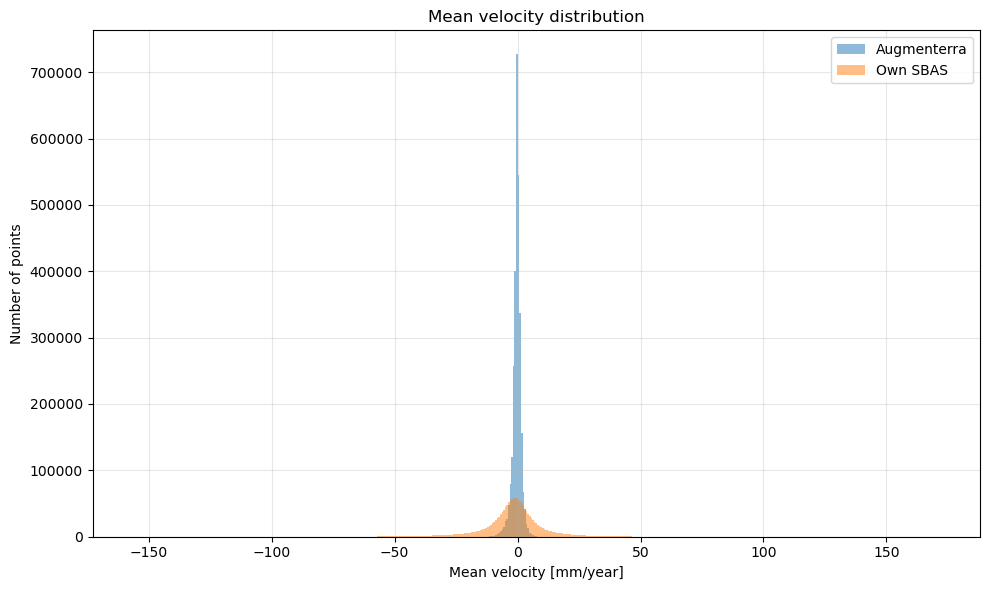

In [28]:
velocity_all = pd.concat([
    augmenterra[AUGMENTERRA_VELOCITY_COL],
    own[OWN_VELOCITY_COL]
]).dropna()

# Use common range
v_min = velocity_all.min()
v_max = velocity_all.max()

bins = np.linspace(v_min, v_max, 500)


plt.figure(figsize=(10, 6))

plt.hist(
    augmenterra[AUGMENTERRA_VELOCITY_COL].dropna(),
    bins=bins,
    alpha=0.5,
    label="Augmenterra",
)

plt.hist(
    own[OWN_VELOCITY_COL].dropna(),
    bins=bins,
    alpha=0.5,
    label="Own SBAS",
)

plt.xlabel("Mean velocity [mm/year]")
plt.ylabel("Number of points")
plt.title("Mean velocity distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

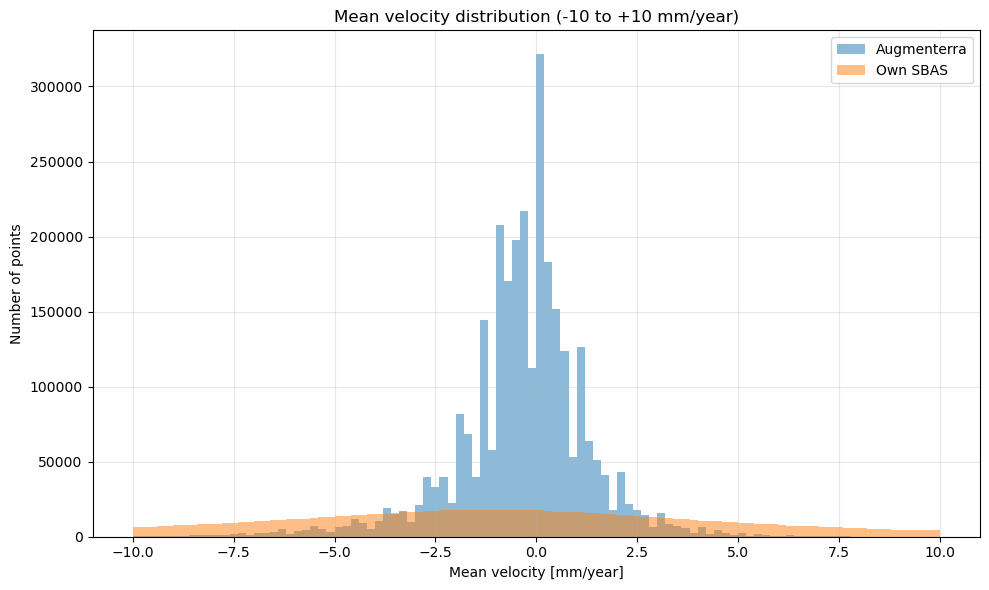

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    augmenterra[AUGMENTERRA_VELOCITY_COL].dropna(),
    bins=100,
    range=(-10, 10),
    alpha=0.5,
    label="Augmenterra",
)

plt.hist(
    own[OWN_VELOCITY_COL].dropna(),
    bins=100,
    range=(-10, 10),
    alpha=0.5,
    label="Own SBAS",
)

plt.xlabel("Mean velocity [mm/year]")
plt.ylabel("Number of points")
plt.title("Mean velocity distribution (-10 to +10 mm/year)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()